In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/009/583/original/data_%281%29.csv")

In [ ]:
df

,X,Y
0,1,1.0
1,2,-3.0
2,2,4.0
3,-3,-1.0
4,4,-2.0
5,-5,-5.0
6,1,2.0
7,-1,-1.0
8,4,-5.0
9,2,-10.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
st = MinMaxScaler()
df = st.fit_transform(df)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
def plot(X, kmeans, initial_centers, final_centers):
    # 4. Plotting
    plt.figure(figsize=(8, 6))

    # Plot the data points colored by their final cluster label
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.4)

    # Mark the INITIAL centers (Red X)
    plt.scatter(initial_centers[:, 0], initial_centers[:, 1],
                marker='x', s=200, color='red', label='Initial Seeds')

    # Mark the FINAL centers (Black Star)
    plt.scatter(final_centers[:, 0], final_centers[:, 1],
                marker='*', s=200, color='black', label='Final Centroids')

    # Draw arrows showing the movement
    for i in range(len(initial_centers)):
        plt.annotate('', xy=final_centers[i], xytext=initial_centers[i],
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, ls='--'))

    plt.title("K-Means Centroid Migration")
    plt.legend()
    plt.show()

In [ ]:
# 5. Centered Plotting Function
def plot_centered(X, kmeans, initial_centers, final_centers):
    plt.figure(figsize=(8, 8)) # Square aspect ratio for symmetry

    # Force X to be a numpy array to avoid Indexing errors
    if isinstance(X, pd.DataFrame):
        X = X.values

    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.3, label='Data')

    # Plot Initial Centers (Red X)
    plt.scatter(initial_centers[:, 0], initial_centers[:, 1],
                marker='x', s=200, color='red', label='Initial Seeds', zorder=5)

    # Plot Final Centroids (Black Star)
    plt.scatter(final_centers[:, 0], final_centers[:, 1],
                marker='*', s=250, color='black', edgecolors='white', label='Final Centroids', zorder=6)

    # Draw movement arrows
    for i in range(len(initial_centers)):
        plt.annotate('', xy=final_centers[i], xytext=initial_centers[i],
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5, ls='--'))

    # Centering Logic: find the absolute max to set symmetric limits
    limit = max(np.abs(X).max(), np.abs(initial_centers).max(), np.abs(final_centers).max()) * 1.2
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)

    # Visual Origin
    plt.axhline(0, color='black', linewidth=1, alpha=0.3)
    plt.axvline(0, color='black', linewidth=1, alpha=0.3)

    plt.title("K-Means: Seed Migration (Centered at 0,0)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.show()

[[ 2.5         0.9375    ]
 [-3.6        -1.9       ]
 [ 4.33333333 -6.33333333]]


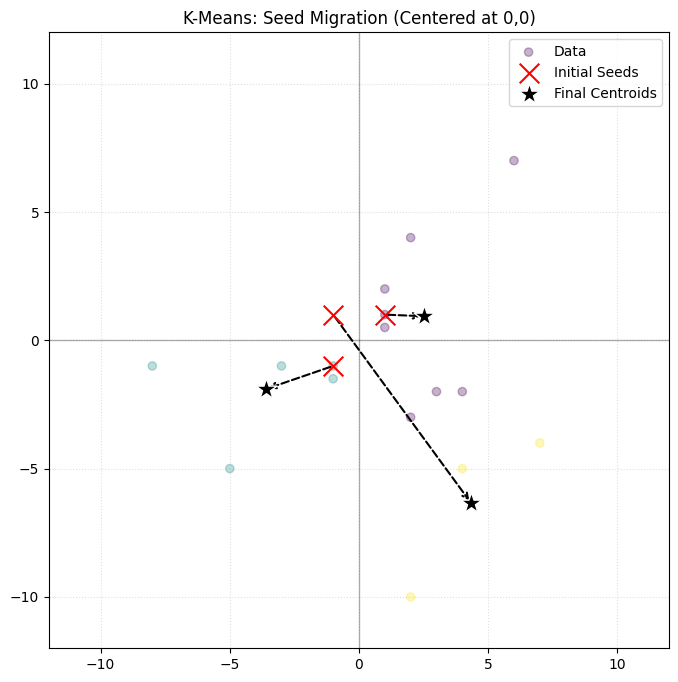

In [ ]:
my_init_centers = np.array([(1, 1), (-1, -1), (-1, 1)])
model = KMeans(n_clusters=3, init = my_init_centers, n_init = 1)
model.fit_predict(df)
print(model.cluster_centers_)
plot_centered(df, model, my_init_centers, model.cluster_centers_)

[[ 2.2         2.9       ]
 [-3.6        -1.9       ]
 [ 3.66666667 -4.33333333]]


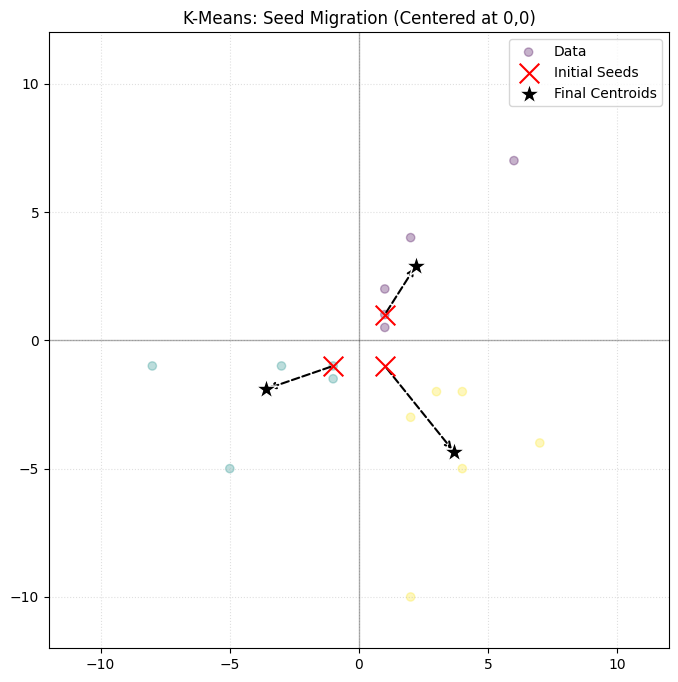

In [ ]:
my_init_centers = np.array([(1, 1), (-1, -1), (1, -1)])
model = KMeans(n_clusters=3, init = my_init_centers, n_init = 1)
model.fit_predict(df)
print(model.cluster_centers_)
plot_centered(df, model, my_init_centers, model.cluster_centers_)

[[  3.1   -0.15]
 [ -3.6   -1.9 ]
 [  2.   -10.  ]]


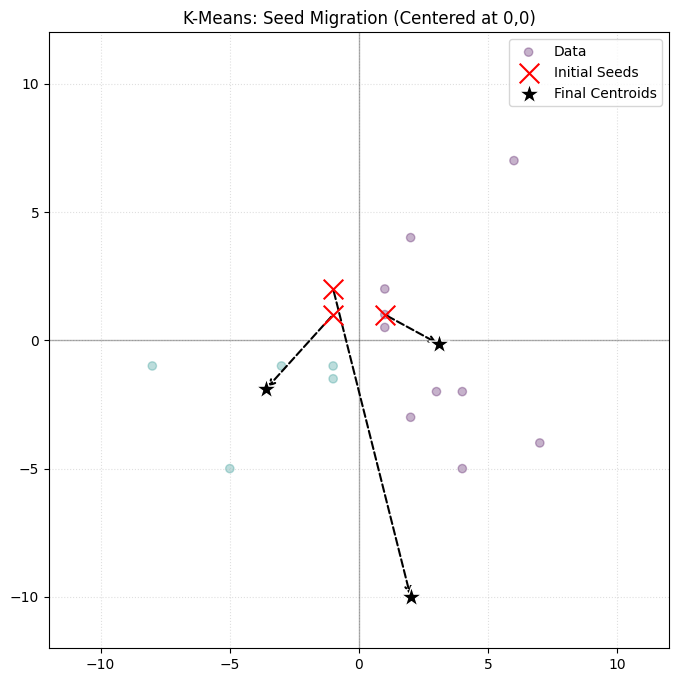

In [ ]:
my_init_centers = np.array([(1, 1), (-1, 1), (-1, 2)])
model = KMeans(n_clusters=3, init = my_init_centers, n_init = 1)
model.fit_predict(df)
print(model.cluster_centers_)
plot_centered(df, model, my_init_centers, model.cluster_centers_)

In [4]:
X = np.array([(1,2),(2,3),(-1,-2),(3,4),(4,-2),(3,-3),(-5,-4),(3,10),(-3,-4),(7,9),(6,5),(3,-4),(-4,-3),(-1,-5),(-5,-8),(6,7),(4,-5),(0,0),(-3,-5)])

In [6]:
X = pd.DataFrame(X)

In [8]:
X.columns = ['x', 'y']

In [9]:
X

,x,y
0,1,2
1,2,3
2,-1,-2
3,3,4
4,4,-2
5,3,-3
6,-5,-4
7,3,10
8,-3,-4
9,7,9


In [17]:
c1 = (-3, -5)
c2 = (3, 4)

In [36]:
import numpy as np
import pandas as pd

# 1. Calculate distance to EACH centroid
d1 = np.sum((X - c1)**2, axis=1)
d2 = np.sum((X - c2)**2, axis=1)

# 2. Find distance to the NEAREST centroid for each point
min_dist = np.minimum(d1, d2)

# 4. Calculate probabilities (D^2 sampling)
probabilities = min_dist / np.sum(min_dist)

# 5. Create DataFrame
f = pd.DataFrame(X, columns=['x', 'y'])
f['p'] = probabilities
f = f.sort_values(by='p', ascending=False)

In [37]:
f

,x,y,p
16,4,-5,0.142442
9,7,9,0.119186
5,3,-3,0.116279
11,3,-4,0.107558
4,4,-2,0.107558
7,3,10,0.104651
17,0,0,0.072674
15,6,7,0.052326
14,-5,-8,0.037791
2,-1,-2,0.037791


In [39]:
f.index

Index([16, 9, 5, 11, 4, 7, 17, 15, 14, 2, 10, 0, 6, 12, 13, 1, 8, 3, 18], dtype='int64')

In [42]:
np.random.choice(f.index, p=f['p'])

np.int64(11)

In [44]:
# 6. Randomly pick the index of the 3rd centroid based on your probabilities
# 'p' is the column you just created in your DataFrame 'f'
third_centroid_idx = np.random.choice(f.index, p=f['p'])

# 7. Get the actual coordinates (x, y) for c3
c3 = X.loc[third_centroid_idx]

print(f"The 3rd centroid is located at: {c3.x, c3.y}")

The 3rd centroid is located at: (np.int64(-5), np.int64(-8))
